<a href="https://colab.research.google.com/github/Nahom32/Cow-Anomaly-Detection/blob/main/notebooks/Cow_Anomaly_VAE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install ultralytics scipy torch torchvision pytorchvideo decord opencv-python tqdm pandas kagglehub

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.7/132.7 kB 6.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 2.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 2.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 33.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.6/13.6 MB 59.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.3/36.3 MB 17.7 MB/s eta 0:00:00
  Created wheel for pytorchvideo: filename=pytorchvideo-0.1.5-py3-none-any.whl size=188686 sha256=1bfc37e7f43448495f6395e0419c9d7dbcd0435dd00742f2cc0980645c1c034c
  Stored in directory: /root/.cache/pip/wheels/b3/49/dc/aab2dce83e38b59849db13a4f4ddd220e568e24b58332fb0f9
  Created wheel for fvcore: filename=fvcore-0.1.5.post20221221-py3-none-any.whl size=61397 sha256=4653aaeb04f16402454e098367bddc003

In [ ]:
import kagglehub

path = kagglehub.dataset_download("fandaoerji/cbvd-5cow-behavior-video-dataset")
print(path)
import os

for d in os.listdir(path):
    print(d)

100%|██████████| 10.8G/10.8G [02:01<00:00, 95.9MB/s]

Extracting files...


/root/.cache/kagglehub/datasets/fandaoerji/cbvd-5cow-behavior-video-dataset/versions/11
miniannotations
labelframes_add
annotations
minilabelframes
labelframes
videos
CBVD-5.csv
rawframes_mini
videos_add


In [ ]:
import os
import cv2
import numpy as np
import pandas as pd
from pathlib import Path
from collections import defaultdict
import shutil
from tqdm import tqdm
from sklearn.model_selection import GroupShuffleSplit

# YOLO
from ultralytics import YOLO
from google.colab import drive, files
drive.mount('/content/drive')

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Mounted at /content/drive


In [ ]:
model = YOLO("/content/drive/MyDrive/cow_detector26n_results/weights/best.pt")

#Feature Extraction Layer Using YOLO26n after the SPPF block

In [ ]:
pt_model = model.model

# We'll get the features after the SPPF block (layer 9 in the printed model summary).
target_layer = pt_model.model[9]   # adjust based on your model architecture

features = []

def hook_fn(module, input, output):
    # output shape: (batch, channels, height, width)
    features.append(output.detach())

hook = target_layer.register_forward_hook(hook_fn)


In [ ]:
import torch
import torchvision.transforms as transforms

def extract_cow_features(img, bbox, feature_extractor, device='cuda', normalize=True):
    """
    Extract deep features from a cow bounding box.

    Args:
        img: numpy array (H,W,3) in BGR or RGB format
        bbox: (x1, y1, x2, y2) bounding box coordinates (absolute pixel values)
        feature_extractor: PyTorch model (e.g., YOLO backbone) that returns a feature vector/tensor
        device: 'cuda' or 'cpu'
        normalize: if True, apply ImageNet normalization (mean/std)

    Returns:
        feature_vector: numpy array of shape (feature_dim,)
    """
    x1_orig, y1_orig, x2_orig, y2_orig = bbox # Keep original for error message if needed

    # 1. Convert to integer and clamp to image dimensions
    h, w = img.shape[:2]
    x1 = max(0, round(x1_orig))
    y1 = max(0, round(y1_orig))
    x2 = min(w, round(x2_orig))
    y2 = min(h, round(y2_orig))

    # 2. Ensure minimum 1-pixel dimension for slicing
    # If width/height is zero or negative after rounding/clamping, expand to 1 pixel.
    if x2 <= x1:
        x2 = x1 + 1
        if x2 > w: # if incrementing x2 goes past image boundary, try decrementing x1
            x2 = w
            x1 = w - 1
            if x1 < 0: return None # Image too small for 1 pixel width
    if y2 <= y1:
        y2 = y1 + 1
        if y2 > h: # if incrementing y2 goes past image boundary, try decrementing y1
            y2 = h
            y1 = h - 1
            if y1 < 0: return None # Image too small for 1 pixel height

    # After adjustments, re-clamp (important if x1/y1 was adjusted and went < 0, or x2/y2 went > w/h)
    x1 = max(0, x1)
    y1 = max(0, y1)
    x2 = min(w, x2)
    y2 = min(h, y2)

    # Final check for validity before crop (should be covered by above logic, but for robustness)
    if x1 >= x2 or y1 >= y2:
        return None

    # 3. Perform crop
    crop = img[y1:y2, x1:x2]

    # Explicitly check for empty crop and return None to prevent errors in cv2.resize
    if crop.size == 0:
        return None

    crop = cv2.resize(crop, (224, 224))

    # 3. Convert color space (if needed)
    # Assuming img is BGR (OpenCV default). Convert to RGB for models pretrained on ImageNet
    crop_rgb = cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)

    # 4. Transform to tensor and normalize
    transform_list = [transforms.ToTensor()]
    if normalize:
        # Standard ImageNet normalization (most pretrained models expect this)
        transform_list.append(transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                                   std=[0.229, 0.224, 0.225]))
    transform = transforms.Compose(transform_list)
    input_tensor = transform(crop_rgb).unsqueeze(0)  # add batch dimension

    # 5. Move to device
    input_tensor = input_tensor.to(device)

    # 6. Extract features
    with torch.no_grad():
        feat = feature_extractor(input_tensor)

    # 7. Convert to numpy vector (handle different output shapes)
    if isinstance(feat, (tuple, list)):
        # If feature_extractor returns multiple outputs (e.g., with hooks), take first one
        feat = feat[0]
    if feat.dim() > 2:
        # If output is a feature map (C, H, W), apply global average pooling
        feat = feat.mean(dim=[2, 3])
    feature_vector = feat.cpu().numpy().flatten()

    return feature_vector

In [ ]:
features = []
def hook_fn(module, inp, out):
    features.append(out.detach())

hook = pt_model.model[9].register_forward_hook(hook_fn)

# Then define a wrapper that returns the captured feature
def yolo_feature_extractor(x):
    global features
    features = []
    _ = pt_model(x)
    return features[0]

# Move pt_model to the correct device and set to eval mode once
device = 'cuda' if torch.cuda.is_available() else 'cpu'
pt_model.to(device)
pt_model.eval()

# Extract feature from an image
# img = cv2.imread("frame.jpg")
# bbox = (100, 200, 300, 400)  # example
# feat_vec = extract_cow_features(img, bbox, yolo_feature_extractor)
# print(feat_vec.shape)

DetectionModel(
  (model): Sequential(
    (0): Conv(
      (conv): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (bn): BatchNorm2d(16, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
      (act): SiLU(inplace=True)
    )
    (1): Conv(
      (conv): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
      (act): SiLU(inplace=True)
    )
    (2): C3k2(
      (cv1): Conv(
        (conv): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (cv2): Conv(
        (conv): Conv2d(48, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn): BatchNorm2d(64, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
   

In [ ]:
import os
for i in os.walk("/root/.cache/kagglehub/datasets/fandaoerji/cbvd-5cow-behavior-video-dataset/versions/11/videos/"):
  print(i)


('/root/.cache/kagglehub/datasets/fandaoerji/cbvd-5cow-behavior-video-dataset/versions/11/videos/', ['videos'], [])
('/root/.cache/kagglehub/datasets/fandaoerji/cbvd-5cow-behavior-video-dataset/versions/11/videos/videos', [], ['46.mp4', '520.mp4', '564.mp4', '198.mp4', '112.mp4', '657.mp4', '83.mp4', '535.mp4', '274.mp4', '105.mp4', '339.mp4', '411.mp4', '530.mp4', '228.mp4', '559.mp4', '135.mp4', '340.mp4', '621.mp4', '439.mp4', '304.mp4', '675.mp4', '66.mp4', '248.mp4', '312.mp4', '285.mp4', '596.mp4', '354.mp4', '664.mp4', '623.mp4', '669.mp4', '650.mp4', '90.mp4', '654.mp4', '301.mp4', '160.mp4', '341.mp4', '165.mp4', '551.mp4', '130.mp4', '388.mp4', '410.mp4', '64.mp4', '586.mp4', '242.mp4', '383.mp4', '537.mp4', '572.mp4', '357.mp4', '393.mp4', '79.mp4', '110.mp4', '266.mp4', '48.mp4', '495.mp4', '477.mp4', '49.mp4', '636.mp4', '379.mp4', '225.mp4', '257.mp4', '385.mp4', '580.mp4', '345.mp4', '208.mp4', '268.mp4', '576.mp4', '361.mp4', '14.mp4', '31.mp4', '132.mp4', '250.mp4', '4

In [ ]:
DATA_ROOT = "/root/.cache/kagglehub/datasets/fandaoerji/cbvd-5cow-behavior-video-dataset/versions/11"
ANNOTATIONS_DIR = os.path.join(DATA_ROOT, "annotations")      # full annotations
FRAMES_DIR = os.path.join(DATA_ROOT, "rawframes_mini")       # adjust to your frames folder
OUTPUT_DIR = "/content/cow_detection_dataset_fixed"
FPS = 25
TRAIN_RATIO = 0.8
RANDOM_SEED = 42
ann_file = os.path.join(ANNOTATIONS_DIR, "ava_train_v2.1.csv")
df = pd.read_csv(ann_file, header=None, dtype={0: str})
df.columns = ["video_id", "timestamp", "x1", "y1", "x2", "y2", "action_id", "target_id"]
print(f"Raw annotations: {len(df)}")
valid_video_ids = set(os.listdir(FRAMES_DIR))
df = df[df["video_id"].isin(valid_video_ids)].copy()
print(f"After filtering by existing video folders: {len(df)}")

Raw annotations: 34102
After filtering by existing video folders: 34025


In [ ]:
boxes_per_image = defaultdict(set)

for _, row in tqdm(df.iterrows(), total=len(df), desc="Grouping & dedup"):
    video_id = str(row["video_id"])
    frame_idx = int(row["timestamp"] * FPS)
    img_path = Path(FRAMES_DIR) / video_id / f"img_{frame_idx:05d}.jpg"

    if not img_path.exists():
        continue

    # Get normalized bounding box (already normalized in CSV)
    x1 = max(0.0, min(1.0, row["x1"]))
    x2 = max(0.0, min(1.0, row["x2"]))
    y1 = max(0.0, min(1.0, row["y1"]))
    y2 = max(0.0, min(1.0, row["y2"]))

    if x1 >= x2 or y1 >= y2:
        continue

    # Convert to YOLO format (center, width, height)
    x_center = (x1 + x2) / 2.0
    y_center = (y1 + y2) / 2.0
    width = x2 - x1
    height = y2 - y1

    # Use a tuple of 4 floats as the key for deduplication
    box_key = (round(x_center, 6), round(y_center, 6), round(width, 6), round(height, 6))

    image_key = f"{video_id}_{frame_idx:05d}"
    boxes_per_image[image_key].add( (str(img_path), box_key) )

print(f"Unique images with at least one cow: {len(boxes_per_image)}")

Grouping & dedup: 100%|██████████| 34025/34025 [00:03<00:00, 10677.90it/s]

Unique images with at least one cow: 2921


In [ ]:
all_video_ids = list(set(key.split("_")[0] for key in boxes_per_image.keys()))
splitter = GroupShuffleSplit(n_splits=1, test_size=1-TRAIN_RATIO, random_state=RANDOM_SEED)
train_idx, val_idx = next(splitter.split(all_video_ids, groups=all_video_ids))

train_videos = set([all_video_ids[i] for i in train_idx])
val_videos = set([all_video_ids[i] for i in val_idx])
print(f"Train videos: {len(train_videos)}, Val videos: {len(val_videos)}")

Train videos: 392, Val videos: 99


In [ ]:
from pathlib import Path
import shutil
from tqdm import tqdm

# Create output directories for images and labels
for s in ["train", "val"]:
    os.makedirs(Path(OUTPUT_DIR) / s / "images", exist_ok=True)
    os.makedirs(Path(OUTPUT_DIR) / s / "labels", exist_ok=True)

for image_key, box_set in tqdm(boxes_per_image.items(), desc="Writing dataset"):
    video_id = image_key.split("_")[0]
    split = "val" if video_id in val_videos else "train"

    # Get the image path (any element from the set, all have same path)
    img_path = next(iter(box_set))[0]

    # Copy image to destination
    dest_img = Path(OUTPUT_DIR) / split / "images" / f"{image_key}.jpg"
    if not dest_img.exists():
        shutil.copy(img_path, dest_img)

    # Write label file with one line per unique box
    label_path = Path(OUTPUT_DIR) / split / "labels" / f"{image_key}.txt"
    with open(label_path, "w") as f:
        for _, box_key in box_set:
            xc, yc, w, h = box_key
            f.write(f"0 {xc:.6f} {yc:.6f} {w:.6f} {h:.6f}\n")

print(f"Dataset ready at {OUTPUT_DIR}")

Writing dataset: 100%|██████████| 2921/2921 [00:04<00:00, 660.19it/s]

Dataset ready at /content/cow_detection_dataset_fixed


In [ ]:
for i in os.walk("/content/cow_detection_dataset_fixed/"):
  print(i)


('/content/cow_detection_dataset_fixed/', ['train', 'val'], [])
('/content/cow_detection_dataset_fixed/train', ['labels', 'images'], [])
('/content/cow_detection_dataset_fixed/train/labels', [], ['271_00150.txt', '250_00175.txt', '334_00125.txt', '605_00100.txt', '639_00050.txt', '304_00100.txt', '254_00075.txt', '345_00150.txt', '674_00125.txt', '594_00125.txt', '121_00075.txt', '664_00175.txt', '259_00175.txt', '121_00125.txt', '671_00175.txt', '227_00175.txt', '23_00100.txt', '515_00150.txt', '4_00075.txt', '681_00100.txt', '316_00100.txt', '343_00125.txt', '298_00075.txt', '219_00125.txt', '200_00150.txt', '98_00075.txt', '147_00100.txt', '101_00150.txt', '658_00075.txt', '242_00175.txt', '496_00100.txt', '252_00050.txt', '13_00175.txt', '301_00150.txt', '318_00150.txt', '245_00125.txt', '481_00125.txt', '579_00100.txt', '291_00100.txt', '188_00150.txt', '255_00050.txt', '243_00050.txt', '257_00075.txt', '191_00075.txt', '271_00125.txt', '14_00050.txt', '584_00125.txt', '345_00175.

In [ ]:
img = cv2.imread(f"/content/cow_detection_dataset_fixed/val/images/108_00050.jpg")
bbox = (100, 200, 300, 400)  # example
feat_vec = extract_cow_features(img, bbox, yolo_feature_extractor)
print(feat_vec.shape)

(256,)


In [ ]:
import torch.nn as nn
import torch.nn.functional as F

class VAE(nn.Module):
    def __init__(self, input_dim, hidden_dim=128, latent_dim=32):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU()
        )
        self.fc_mu = nn.Linear(hidden_dim, latent_dim)
        self.fc_logvar = nn.Linear(hidden_dim, latent_dim)
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, input_dim),
            nn.Sigmoid()
        )

    def encode(self, x):
        h = self.encoder(x)
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        return self.decoder(z)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        recon = self.decode(z)
        return recon, mu, logvar

In [ ]:
def loss_function(recon, x, mu, logvar):
    BCE = F.mse_loss(recon, x, reduction='sum')
    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return BCE + KLD

# Assume `X_train` is a numpy array of normal features (N × input_dim)
# Normalise features (e.g., StandardScaler) for stable training

In [ ]:
import torch.nn.functional as F

def vae_loss(recon_x, x, mu, logvar, reduction='sum'):
    """
    Compute VAE loss = reconstruction loss + KL divergence

    Args:
        recon_x: reconstructed input
        x: original input
        mu: mean from encoder
        logvar: log variance from encoder
        reduction: 'sum' or 'mean' (affects magnitude)

    Returns:
        total_loss, reconstruction_loss, kl_loss (all scalars)
    """
    # Reconstruction loss (binary cross entropy or MSE)
    recon_loss = F.mse_loss(recon_x, x, reduction=reduction)
    # recon_loss = F.binary_cross_entropy(recon_x, x, reduction=reduction)  # for pixel values in [0,1]

    # KL divergence = -0.5 * sum(1 + log(sigma^2) - mu^2 - sigma^2)
    kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())

    total_loss = recon_loss + kl_loss
    return total_loss, recon_loss, kl_loss

In [ ]:
def train_vae(vae, train_loader, val_loader, epochs, lr=1e-3, device='cuda'):
    vae.to(device)
    optimizer = torch.optim.Adam(vae.parameters(), lr=lr)

    history = {
        'epoch': [], 'train_loss': [], 'train_recon': [], 'train_kl': [],
        'val_loss': [], 'val_recon': [], 'val_kl': []
    }

    for epoch in range(1, epochs + 1):
        # Training
        vae.train()
        train_loss, train_recon, train_kl = 0.0, 0.0, 0.0
        for batch in train_loader:
            x = batch[0].to(device) # Access the tensor from the batch and move it to device
            optimizer.zero_grad()
            recon, mu, logvar = vae(x)
            loss, recon_loss, kl_loss = vae_loss(recon, x, mu, logvar, reduction='sum')
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            train_recon += recon_loss.item()
            train_kl += kl_loss.item()

        n_batches = len(train_loader)
        history['epoch'].append(epoch)
        history['train_loss'].append(train_loss / n_batches)
        history['train_recon'].append(train_recon / n_batches)
        history['train_kl'].append(train_kl / n_batches)

        # Validation
        if val_loader:
            vae.eval()
            val_loss, val_recon, val_kl = 0.0, 0.0, 0.0
            with torch.no_grad():
                for batch in val_loader:
                    x = batch[0].to(device) # Access the tensor from the batch and move it to device
                    recon, mu, logvar = vae(x)
                    loss, recon_loss, kl_loss = vae_loss(recon, x, mu, logvar, reduction='sum')
                    val_loss += loss.item()
                    val_recon += recon_loss.item()
                    val_kl += kl_loss.item()
            n_val = len(val_loader)
            history['val_loss'].append(val_loss / n_val)
            history['val_recon'].append(val_recon / n_val)
            history['val_kl'].append(val_kl / n_val)
            print(f"Epoch {epoch:3d} | Train Loss: {history['train_loss'][-1]:.4f} | Val Loss: {history['val_loss'][-1]:.4f}")
        else:
            print(f"Epoch {epoch:3d} | Train Loss: {history['train_loss'][-1]:.4f}")

    return history

In [ ]:
def save_history(history, filename='training_history.csv'):
    pd.DataFrame(history).to_csv(filename, index=False)

In [ ]:
import matplotlib.pyplot as plt
def plot_history(history):
    epochs = history['epoch']
    plt.figure(figsize=(12,4))
    plt.subplot(1,3,1)
    plt.plot(epochs, history['train_loss'], label='Train')
    if 'val_loss' in history and history['val_loss']:
        plt.plot(epochs, history['val_loss'], label='Val')
    plt.xlabel('Epoch')
    plt.ylabel('Total Loss')
    plt.legend()

    plt.subplot(1,3,2)
    plt.plot(epochs, history['train_recon'], label='Train Recon')
    if 'val_recon' in history and history['val_recon']:
        plt.plot(epochs, history['val_recon'], label='Val Recon')
    plt.xlabel('Epoch')
    plt.ylabel('Reconstruction Loss')

    plt.subplot(1,3,3)
    plt.plot(epochs, history['train_kl'], label='Train KL')
    if 'val_kl' in history and history['val_kl']:
        plt.plot(epochs, history['val_kl'], label='Val KL')
    plt.xlabel('Epoch')
    plt.ylabel('KL Divergence')
    plt.tight_layout()
    plt.show()


In [ ]:
def build_feature_dataset(df, frames_dir, feature_extractor,
                          normal_actions=['standing', 'walking', 'lying'],
                          device='cuda'):
    """
    df: DataFrame with columns: video_id, timestamp, x1, y1, x2, y2, action_id, target_id
    frames_dir: root directory of extracted frames (same as FRAMES_DIR in your notebook)
    feature_extractor: function that returns a feature vector from a crop tensor
    normal_actions: list of action names to consider as normal (you need to map action_id to name)
    """
    # Map action_id to name – adjust according to your CSV (action_id numbers)
    # For CBVD-5, you may have a separate mapping. We'll assume you know the mapping.
    # For simplicity, we'll accept a list of action_id integers instead of names.
    # Let's assume normal_action_ids = [0,1,2] (example)
    normal_action_ids = [0, 1, 2]   # CHANGE THIS to match your dataset

    features = []
    for idx, row in tqdm(df.iterrows(), total=len(df)):
        if row['action_id'] not in normal_action_ids:
            continue
        video_id = str(row['video_id'])
        frame_idx = int(row['timestamp'] * 25)   # FPS=25 as in your notebook
        img_path = os.path.join(frames_dir, video_id, f"img_{frame_idx:05d}.jpg")
        if not os.path.exists(img_path):
            continue
        img = cv2.imread(img_path)
        bbox = (row['x1'], row['y1'], row['x2'], row['y2'])
        feat = extract_cow_features(img, bbox, feature_extractor, device=device)
        if feat is not None:
            features.append(feat)
    return np.array(features)

In [ ]:
# --- User settings (adjust these) ---
YOLO_MODEL_PATH = "/content/drive/MyDrive/cow_detector26n_results/weights/best.pt"
FRAMES_DIR = "/root/.cache/kagglehub/datasets/fandaoerji/cbvd-5cow-behavior-video-dataset/versions/11/rawframes_mini"
ANNOTATIONS_CSV = "/root/.cache/kagglehub/datasets/fandaoerji/cbvd-5cow-behavior-video-dataset/versions/11/annotations/ava_train_v2.1.csv"
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

# Load annotations
df = pd.read_csv(ANNOTATIONS_CSV, header=None, dtype={0: str})
df.columns = ["video_id", "timestamp", "x1", "y1", "x2", "y2", "action_id", "target_id"]

In [ ]:
def create_feature_extractor(yolo_model_path, layer_index=9, device='cuda'):
    """
    Load YOLO model and return a function that extracts features from a given layer.
    """
    model = YOLO(yolo_model_path)
    pt_model = model.model
    pt_model.to(device) # Move model to the specified device
    features = []

    def hook_fn(module, inp, out):
        features.append(out.detach())

    hook = pt_model.model[layer_index].register_forward_hook(hook_fn)

    def extractor(x):
        features.clear()
        _ = pt_model(x)
        # Global average pooling to get a vector
        feat_map = features[0]
        feat_vec = feat_map.mean(dim=[2, 3]).squeeze()
        return feat_vec

    return extractor, hook

In [ ]:
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

print("Loading YOLO feature extractor...")
feature_extractor, hook = create_feature_extractor(YOLO_MODEL_PATH, layer_index=9, device=DEVICE)

# Build feature dataset (normal behaviour only)
print("Extracting features from normal behaviour frames...")
# IMPORTANT: replace normal_action_ids with the correct integers for your dataset
# For example, if action_id 0=standing, 1=walking, 2=lying, etc.
normal_action_ids = [0, 1, 2]   # <-- ADAPT THIS
features = []
for idx, row in tqdm(df.iterrows(), total=len(df)):
    if row['action_id'] not in normal_action_ids:
        continue
    video_id = str(row['video_id'])
    frame_idx = int(row['timestamp'] * 25)
    img_path = os.path.join(FRAMES_DIR, video_id, f"img_{frame_idx:05d}.jpg")
    # print(img_path) # Removed for less verbose output
    if not os.path.exists(img_path):
        continue
    img = cv2.imread(img_path)
    if img is None: # Added check for successful image loading
        print(f"Warning: Could not load image {img_path}. Skipping.")
        continue

    h_img, w_img, _ = img.shape
    # Denormalize bounding box coordinates
    bbox_abs = (row['x1'] * w_img, row['y1'] * h_img, row['x2'] * w_img, row['y2'] * h_img)
    # img.view() # This line was incorrect and has been removed
    feat = extract_cow_features(img, bbox_abs, feature_extractor, device=DEVICE)
    if feat is not None:
        features.append(feat)
features = np.array(features)
print(f"Extracted {features.shape[0]} feature vectors of dimension {features.shape[1]}")

# Normalise features (0-1 range for sigmoid output)


Loading YOLO feature extractor...
Extracting features from normal behaviour frames...


100%|██████████| 34102/34102 [08:10<00:00, 69.51it/s]


Extracted 22749 feature vectors of dimension 256
Starting VAE training...


AttributeError: 'list' object has no attribute 'to'

Starting VAE training...
Epoch   1 | Train Loss: 306.7745 | Val Loss: 265.3962
Epoch   2 | Train Loss: 257.8889 | Val Loss: 245.6984
Epoch   3 | Train Loss: 241.8343 | Val Loss: 233.2258
Epoch   4 | Train Loss: 234.6059 | Val Loss: 228.4894
Epoch   5 | Train Loss: 231.6891 | Val Loss: 226.4634
Epoch   6 | Train Loss: 230.3359 | Val Loss: 224.7714
Epoch   7 | Train Loss: 230.2928 | Val Loss: 224.0179
Epoch   8 | Train Loss: 228.6046 | Val Loss: 223.8446
Epoch   9 | Train Loss: 228.0085 | Val Loss: 227.2631
Epoch  10 | Train Loss: 227.3941 | Val Loss: 223.8859
Epoch  11 | Train Loss: 227.2758 | Val Loss: 222.3396
Epoch  12 | Train Loss: 227.0015 | Val Loss: 223.4482
Epoch  13 | Train Loss: 227.0937 | Val Loss: 222.6125
Epoch  14 | Train Loss: 226.2979 | Val Loss: 222.7947
Epoch  15 | Train Loss: 226.9632 | Val Loss: 222.5664
Epoch  16 | Train Loss: 226.2584 | Val Loss: 221.4371
Epoch  17 | Train Loss: 226.4126 | Val Loss: 221.6059
Epoch  18 | Train Loss: 225.6664 | Val Loss: 221.8387
Epo

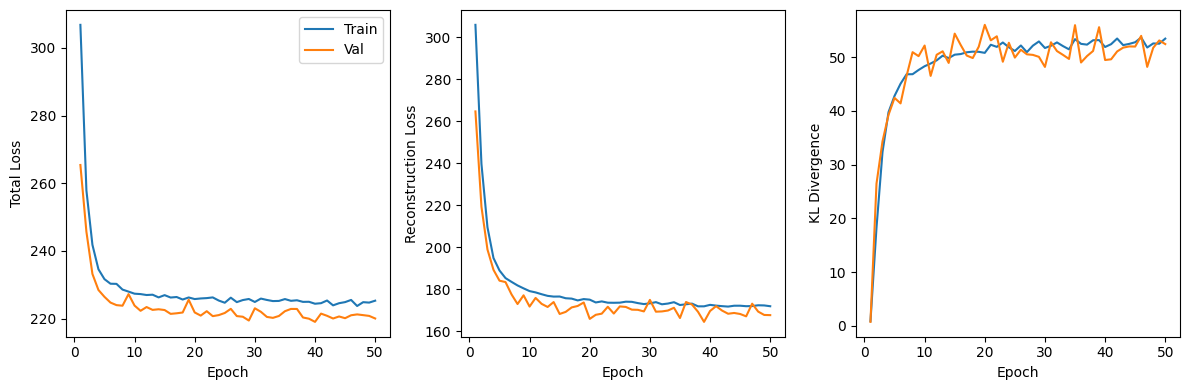

In [ ]:
min_val = features.min(axis=0)
max_val = features.max(axis=0)
features = (features - min_val) / (max_val - min_val + 1e-8)

# Split train/val
X_train, X_val = train_test_split(features, test_size=0.2, random_state=42)
train_loader = DataLoader(TensorDataset(torch.tensor(X_train, dtype=torch.float32)), batch_size=64, shuffle=True)
val_loader = DataLoader(TensorDataset(torch.tensor(X_val, dtype=torch.float32)), batch_size=64, shuffle=False)

# Create VAE
input_dim = features.shape[1]
vae = VAE(input_dim, hidden_dim=128, latent_dim=32)

# Train
print("Starting VAE training...")
history = train_vae(vae, train_loader, val_loader, epochs=50, lr=1e-3, device=DEVICE)

# Save results
save_history(history, 'vae_training_history.csv')
torch.save(vae.state_dict(), 'vae_anomaly_model.pth')
# Save normalisation values for later use
np.save('feature_min.npy', min_val)
np.save('feature_max.npy', max_val)

# Plot
plot_history(history)

hook.remove()

In [ ]:
torch.save(vae.state_dict(), 'vae_anomaly_model.pth')
np.save('feature_min.npy', min_val)
np.save('feature_max.npy', max_val)